In [1]:
addpath(genpath('..'));
pwd



ans = '/Users/jeremy/Downloads/work/prtLab/docs'

Example - Quarter Wave Plate
The simplest example of using prtLab is for a waveplate.  This example is inspired by Example 20.1 in PLAOS.

To start with, we need to define the optical system.  This is implemented using the table type in matlab.  

In [2]:
lambda = 0.633; % um
nO = 1.656;
nE = 1.485;
tQwp = 1.25 * lambda / (nO - nE);
opticAxis = [-sqrt(2)/2; -sqrt(2)/2; 0];

T = createOpticalSystem(lambda);
T.Properties.UserData.lambdaUnits = 'um';

airIndex = struct('n', 1.0);
airAxis = struct();
calciteIndex = struct('nO', nO, 'nE', nE);
calciteAxis = struct('opticAxis', opticAxis);
bareCoating = struct('type', 'bare');

% Object/input space. The zero-thickness row makes the incident medium
% explicit without adding propagation.
T = addSurface( ...
    T, ...
    Inf, ...
    0, ...
    "plane", ...
    struct(), ...
    "isotropic", ...
    airIndex, ...
    airAxis, ...
    bareCoating);

% Plane entrance surface followed by propagation through the calcite plate.
T = addSurface( ...
    T, ...
    Inf, ...
    tQwp, ...
    "plane", ...
    struct(), ...
    "uniaxial", ...
    calciteIndex, ...
    calciteAxis, ...
    bareCoating);

% Plane exit surface into air. Thickness is zero because this row describes
% the output medium after the waveplate.
T = addSurface( ...
    T, ...
    Inf, ...
    0, ...
    "plane", ...
    struct(), ...
    "isotropic", ...
    airIndex, ...
    airAxis, ...
    bareCoating);

This gives a feel on how things are defined.  Materials can either be isotropic or uniaxial, and for uniaxial materials the axis of the extraordinary index needs to be defined as cos vectors.

We can see the output by looking at T.

In [3]:
disp(T)

    Radius    Thickness    SurfaceType    SurfaceData     MaterialType     IndexData        AxisData      CoatingData 
    ______    _________    ___________    ____________    ____________    ____________    ____________    ____________

     Inf            0        "plane"      {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}
     Inf       4.6272        "plane"      {1x1 struct}    "uniaxial"      {1x1 struct}    {1x1 struct}    {1x1 struct}
     Inf            0        "plane"      {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}



You might wonder why to have a o thickness isotropic material here.  The reason is so we can properly add results from nonzero angles of incidence, as we will do later. 

Now let's do a polarization ray trace.  The interface has a few arguments.  We need to specify the optical system (T), the incident k vector and position vector, and the incident E-field

In [4]:
k_in = [0;0;1]; % normal incidence
pos_in = [0;0;0]; % on axis
E_in = [0;1]; % can be 2D or 3D vector
rayOutput = polarizationRayTrace(T, k_in, pos_in, E_in);

Let's look at the output:

In [5]:
disp(rayOutput)


          system: [3x8 table]
         options: [1x1 struct]
            rays: [1x5 struct]
    interactions: [1x3 struct]
     finalRayIds: [4 5]



You can see that there are 5 rays and two finalRayIds.  This is because the uniaxial material generates multiple rays.  There is a tree structure to keep track of things (as suggested in Chapter 19 of PLAOS).

Now we can use the result.  The first thing is to verify it actually produces the correct retardance based on the setup.  This can be done by simply accessing the OPL property for the last two rays.

In [6]:
OPL = rayOutput.rays(rayOutput.finalRayIds(1)).OPL - rayOutput.rays(rayOutput.finalRayIds(2)).OPL; 

OPL_in_waves = OPL/lambda

OPL_in_waves = 1.2500

So this basic test worked.  Now for something slighly more interesting, let's look at the angle of incidence dependence.  Since this is a true 0 order plate, it shouldn't be too sensitive.

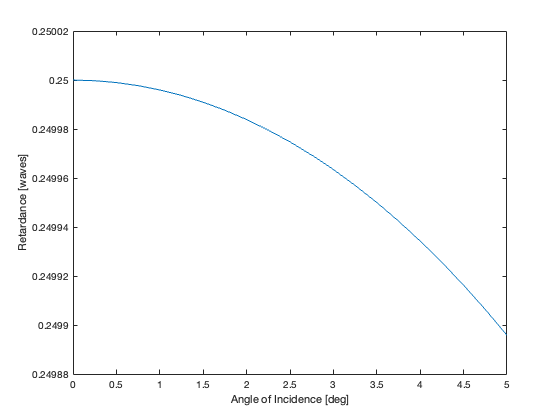

In [7]:
deg = pi/180;

angles = deg*linspace(0,5,21);

for ii=1:length(angles)
    k_in = [0; sin(angles(ii)); cos(angles(ii))];
    rayOutput = polarizationRayTrace(T, k_in, pos_in, E_in);
    OPL = rayOutput.rays(rayOutput.finalRayIds(1)).OPL - rayOutput.rays(rayOutput.finalRayIds(2)).OPL; 

    OPL_vs_AOI(ii) = OPL/lambda;
end

figure;plot(angles/deg, OPL_vs_AOI-1); xlabel('Angle of Incidence [deg]'); ylabel('Retardance [waves]');

As expected, sensitivity is low.  But making a < 5um thick waveplate is not that practical, so let's look at a multi order waveplate. 

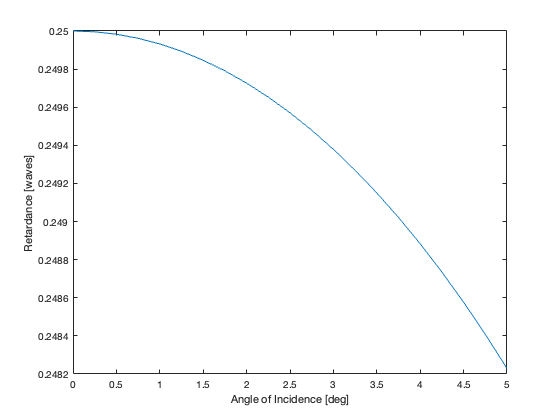

In [8]:
Tm = T;
Tm.Thickness(2) = 17*T.Thickness(2); % integer multiple guarantees Quarter wave at 0 AOI.



for ii=1:length(angles)
    k_in = [0; sin(angles(ii)); cos(angles(ii))];
    rayOutput = polarizationRayTrace(Tm, k_in, pos_in, E_in);
    OPL = rayOutput.rays(rayOutput.finalRayIds(1)).OPL - rayOutput.rays(rayOutput.finalRayIds(2)).OPL; 

    OPL_multiwave_vs_AOI(ii) = OPL/lambda;
end

figure;plot(angles/deg, OPL_multiwave_vs_AOI-21); xlabel('Angle of Incidence [deg]'); ylabel('Retardance [waves]');

The sensitivity is much higher.  As a more visual example, let's look at the situation where the waveplates are placed in a pupil plane with this angular range

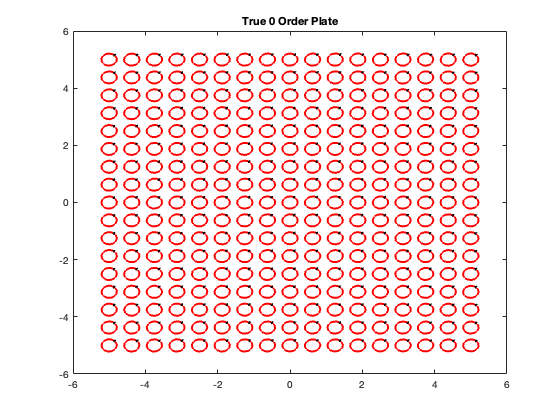

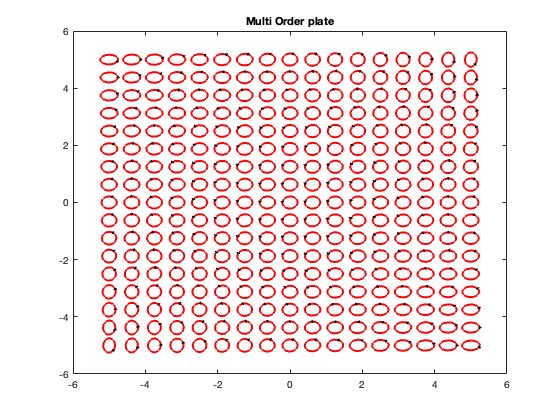

In [9]:
[X,Y] = meshgrid(linspace(-5,5,17)); % assume 10mm diameter pupil
[tX, tY] = meshgrid(linspace(-5,5,17)); % 

coord = struct('type',"doublePole", ...
    'a_loc',[0;0;1], ...
    'x_o',[1;0;0]);

for ii=1:size(tX,1)
    for jj=1:size(tX,2)
        k_in = calcKFromThetaXThetaY(tX(ii,jj), tY(ii,jj));
        pos_in = [X(ii,jj); Y(ii,jj); 0];
        rayOutput = polarizationRayTrace(T, k_in, pos_in, E_in);
        % Can only properly add Ps because output angle is the same after parallel waveplate
        P_tot = rayOutput.rays(rayOutput.finalRayIds(1)).P + rayOutput.rays(rayOutput.finalRayIds(2)).P;
        J = transformPtoJones(P_tot, k_in, rayOutput.rays(rayOutput.finalRayIds(1)).k, coord);
        Jall(ii,jj,:,:) = J;

        rayOutput_m = polarizationRayTrace(Tm, k_in, pos_in, E_in);
        % Can only properly add Ps because output angle is the same after parallel waveplate
        P_tot_m = rayOutput_m.rays(rayOutput_m.finalRayIds(1)).P + rayOutput_m.rays(rayOutput_m.finalRayIds(2)).P;
        J_m = transformPtoJones(P_tot_m, k_in, rayOutput_m.rays(rayOutput_m.finalRayIds(1)).k, coord);
        Jall_m(ii,jj,:,:) = J_m;        
    end
end

plotPolarizationEllipsesAcrossField(X,Y,Jall, E_in); title('True 0 Order Plate');
plotPolarizationEllipsesAcrossField(X,Y,Jall_m, E_in); title('Multi Order plate');







You can see for the multi wave plate that the ellipticity of the beam is getting worse at the edge.  

